In [27]:
import numpy as np
import pandas as pd
import csv
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn import functional as F
from sklearn.metrics import confusion_matrix

### Hyperparameters

In [28]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
batch_size = 1000
max_epoch = 10
train_iters = 5000
alpha = 1e-4
decay = 1e-5
eval_iters = 1000
dropout = 0.5
np.random.seed(0)
torch.manual_seed(0)

### Training Data Reading and Map generation

#### Creating mapping for class to char

In [29]:
maps = open("OCR Neural Network/Datasets/emnist-balanced-mapping.txt",'r')
maps = {int(i):chr(int(j)) for i,j in [line.split() for line in maps.readlines()]}

#### Train Data Reading

In [30]:
# Load training data Set
with open("OCR Neural Network/Datasets/emnist-balanced-train.csv", "r") as f:
    reader = csv.reader(f)
    data_clump = np.array(list(reader), dtype=np.uint8)

#### Test Data Reading

In [31]:
with open("OCR Neural Network/Datasets/emnist-balanced-test.csv", "r") as f:
    reader = csv.reader(f)
    test_data_clump = np.array(list(reader), dtype=np.uint8)

### Data pre processing

In [32]:
#creating the training set
head_train = data_clump[:,0] 
img_px_train = data_clump[:,1:]

#normalizing the data
trainmean = np.mean(img_px_train)
trainstd = np.std(img_px_train)
img_px_train = (img_px_train - trainmean) / trainstd
img_px_train = img_px_train.reshape(-1, 28, 28)

#creating the test set
head_test = test_data_clump[:,0] 
img_px_test = test_data_clump[:,1:]

#normalizing the data
img_px_test = (img_px_test - trainmean) / trainstd
img_px_test = img_px_test.reshape(-1, 28, 28)

In [33]:
'''
No need to reshape and use pillow to convert to image.
EMNIST dataset already has rotations embedded in it.
'''
frame_train = pd.DataFrame({'Label' : head_train,  'Image' : img_px_train.tolist()})
frame_test = pd.DataFrame({'Label' : head_test,  'Image' : img_px_test.tolist()})

In [34]:
def get_batch(split):
    data = frame_train if split == 'train' else frame_test
    data = data.sample(batch_size)
    X = torch.tensor(data['Image'].values.tolist(), dtype=torch.float32).view(-1, 1, 28, 28)
    y = torch.tensor(data['Label'].values.tolist(), dtype=torch.long)
    X,y = X.to(device), y.to(device)
    return X, y

### Designing the CNN Layers for Processing
* A CNN or Convolution Neural Network applies Convultions on values input.

* In a CNN, each node is a convoltuion alogrithm with some specified weight of convolution, a value to multiply the underlying value by. Suppose w1 for n1 is defined as 0.5, then the convolution will take w1*p1 for the case of the output x1

* In the CNN Layer, a 2D Convolution then takes in the entire image (grey scale 1 channel) and spits out a series of maps that with channels of N_out_channels.

* These channels could embed features in the weights or such. Each weight is mapped by the kernel so, if kernal is N size, there will be $N^2$ weights

In [35]:
class CNNLayer(nn.Module):
    #Define the first layer of the CNN
    def __init__(self, *args, **kwargs) -> None:
        super(CNNLayer, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3) # 28x28x1 -> 26x26x32
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2) # 26x26x32 -> 13x13x32

        self.flatten = nn.Flatten()

        self.fc1 = nn.Linear(32*13*13, 512)
        self.fc2 = nn.Linear(512, 128)
        self.fc3 = nn.Linear(128, 47)

        self.activation = nn.GELU()
        self.dropout = nn.Dropout(p=dropout)
        self.output_activation = nn.GELU()
    
    def forward(self, x):
        out = self.conv1(x)
        out = self.activation(out)
        out = self.pool1(out)

        out = self.flatten(out)
        
        out = self.fc1(out)
        out = self.activation(out)

        out = self.fc2(out)
        out = self.activation(out)

        out = self.fc3(out)
        out = self.output_activation(out)

        out = F.softmax(out, dim=1)
        return out

### Creating the Model

In [36]:
class OCRCNN(nn.Module):
    def __init__(self, *args, **kwargs) -> None:
        super(OCRCNN, self).__init__()
        self.hidden = CNNLayer()

    def forward(self, x, train_target = None):
        
        # Run through the Main Hidden Layers of the CNN
        out = self.hidden(x)

        if train_target is not None:
            loss = F.cross_entropy(out, train_target)
            return out, loss
        
        return out,None
    
    def predict(self, frame, size):
        frame = frame.sample(size)
        X = torch.tensor(frame['Image'].values.tolist(), dtype=torch.float32).view(-1, 1, 28, 28)
        y = np.array(frame['Label'].values.tolist(), dtype=np.int64)
        
        X, y = X.to(device), torch.tensor(y).to(device)
        
        self.eval()  # Set model to evaluation mode
        with torch.no_grad():
            out = self.hidden(X)
            _, predicted = torch.max(out, 1)
        
        conf_matrix = confusion_matrix(y.cpu(), predicted.cpu())
        print([maps[i] for i in predicted.cpu().numpy()])
        print([maps[i] for i in y.cpu().numpy()])
        plt.imshow(conf_matrix, cmap='hot', interpolation='nearest')
        plt.colorbar()
        plt.show()
        
        return None

In [11]:
model = OCRCNN()
m = model.to(device)

sum(p.numel() for p in m.parameters()),"parameters"

(2841455, 'parameters')

In [12]:
Counter = 0
train_losses = []
val_losses = []

In [13]:
@torch.no_grad()
def estimate_loss():
    out = {}
    model.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    out['accuracy'] = get_accuracy()
    model.train()
    return out

@torch.no_grad()
def get_accuracy():
    model.eval()
    correct = 0
    total = 0
    for i in range(1000):
        X, Y = get_batch('val')
        logits, _ = model(X, Y)
        _, predicted = torch.max(logits, 1)
        total += Y.size(0)
        correct += (predicted == Y).sum().item()
    model.train()
    return correct / total

In [24]:
#Adjustment For Plateau
aplha = 1e-6
decay = 1e-7

batch_size = 256

max_epoch = 1

In [25]:
optimizer = torch.optim.AdamW(m.parameters(), lr=alpha, weight_decay=decay)

for epoch in range(max_epoch):
    model.train()
    for i in range(train_iters):
        if i % eval_iters == 0 or i == train_iters - 1:
            losses = estimate_loss()
            train_losses.append(losses['train'])
            val_losses.append(losses['val'])
            acc = losses['accuracy']
            print(f'Epoch {epoch}, Iteration {Counter}')
            print(f'Training Loss: {train_losses[-1]:.4f}, Validation Loss: {val_losses[-1]:.4f} : Accuracy: {acc:.4f}')
            Counter += 1000

        
        X_tr, Y_tr = get_batch('train')

        optimizer.zero_grad()

        out,loss = m(X_tr, Y_tr)

        loss.backward()
        optimizer.step()


Epoch 0, Iteration 57000
Training Loss: 3.0301, Validation Loss: 3.0988 : Accuracy: 0.7873
Epoch 0, Iteration 58000
Training Loss: 3.0306, Validation Loss: 3.0986 : Accuracy: 0.7887
Epoch 0, Iteration 59000
Training Loss: 3.0284, Validation Loss: 3.0971 : Accuracy: 0.7914
Epoch 0, Iteration 60000
Training Loss: 3.0286, Validation Loss: 3.0976 : Accuracy: 0.7901
Epoch 0, Iteration 61000
Training Loss: 3.0276, Validation Loss: 3.0978 : Accuracy: 0.7886
Epoch 0, Iteration 62000
Training Loss: 3.0301, Validation Loss: 3.0981 : Accuracy: 0.7882


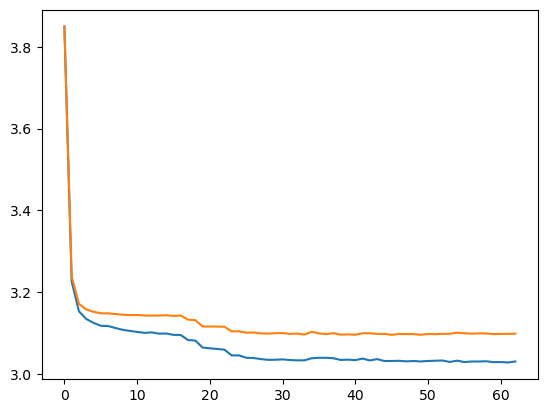

Training Done
['T', '5', 'E', 'Q', 'e', 'M', 'd', 'h', '3', '0', 'M', '1', 'J', 'J', 'b', 'T', '1', 'q', 'Q', 'b', 'E', 'a', 'M', 'C', 'N', '6', 'K', '6', 'q', 'B', 'h', '5', '2', 'B', 'F', 'H', 'b', 'P', 'a', 'Z', 'M', 'D', 'C', 'f', 'C', 'R', 'n', 'I', 'Z', 'H', 'F', '2', '7', '5', '5', 'd', 'n', 'Y', 'h', 'J', '5', '2', 'C', 'Q', 'W', 'R', 'e', 'f', 'b', 'B', '2', 'V', 'q', 'A', 'n', 't', 'W', 'f', 'V', 'K', 'A', 'E', 'C', 'U', 'P', 'I', 'K', '0', 'f', 'G', 'B', 'N', '5', 'e', 't', 'Y', 'V', 'B', 'E', 'W', 'B', '0', 'J', 'g', 'e', 'B', 'J', 'f', 'I', 'B', 'f', 'A', 'Z', 'N', 'T', 'Q', 'E', '7', '2', 'R', 'g', 'N', '3', '2', 'Z', 'I', '1', 'g', 'W', 'U', 'Z', 'C', 'e', 'f', 'b', 'g', '0', 'f', 'J', '5', 'X', 'F', '7', 'U', 'H', 'K', 'Y', '6', 'F', 'G', 'E', '5', '1', 'M', 'R', '5', 'I', 'Z', 'n', 'q', 'R', 'e', 'F', 'q', 'e', '0', 'M', 'B', '0', 'T', '3', '7', 'W', 'b', 'D', '2', 'M', 'I', 'F', 'd', 'a', 'h', '4', 'P', 'K', '5', '4', 'R', 'q', 'X', 'b', 'B', '0', 'K', 'a', '4', 'Y', 

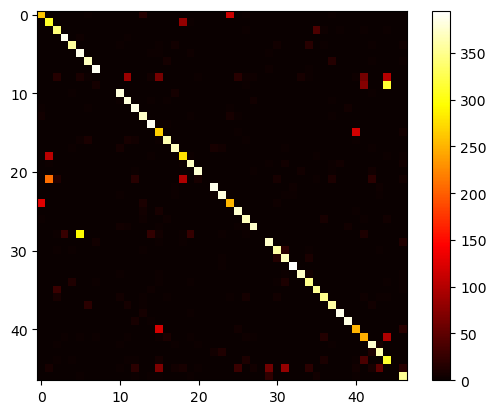

In [26]:
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.show()
print('Training Done')
m.predict(frame_test, frame_test.shape[0])

### Checking State Dicts of Model and Optim

In [35]:
print('Model State Dict')
for param_tensor in model.state_dict():
    print(param_tensor, "\t", model.state_dict()[param_tensor].size())

Model State Dict
hidden.conv1.weight 	 torch.Size([32, 1, 3, 3])
hidden.conv1.bias 	 torch.Size([32])
hidden.fc1.weight 	 torch.Size([512, 5408])
hidden.fc1.bias 	 torch.Size([512])
hidden.fc2.weight 	 torch.Size([128, 512])
hidden.fc2.bias 	 torch.Size([128])
hidden.fc3.weight 	 torch.Size([47, 128])
hidden.fc3.bias 	 torch.Size([47])


In [36]:
print('Optimizer State Dict')
for var_name in optimizer.state_dict():
    print(var_name, "\t", optimizer.state_dict()[var_name])

Optimizer State Dict
state 	 {0: {'step': tensor(5000.), 'exp_avg': tensor([[[[ 1.8190e-04,  1.0201e-04, -6.1365e-04],
          [ 1.6039e-03,  7.8631e-04, -5.0196e-04],
          [ 1.3544e-03,  2.5608e-04,  7.1799e-05]]],


        [[[ 7.1867e-06,  2.3890e-05, -6.1440e-04],
          [ 1.0257e-03,  1.7437e-04, -7.3959e-04],
          [ 5.5955e-04, -2.4857e-04, -1.8681e-04]]],


        [[[ 9.0108e-05,  2.8890e-04, -7.6137e-05],
          [ 4.8413e-04,  8.5229e-04,  5.5305e-04],
          [-4.1085e-04,  9.3053e-05, -1.6534e-04]]],


        [[[-3.1747e-03, -3.6146e-03, -3.4725e-03],
          [-3.4557e-03, -3.5731e-03, -3.5029e-03],
          [-3.2765e-03, -3.3705e-03, -3.0362e-03]]],


        [[[-1.5425e-03, -8.1756e-04, -7.6703e-05],
          [-2.7132e-03, -1.2548e-03,  3.1544e-04],
          [-1.7422e-03, -3.0169e-04,  4.0136e-04]]],


        [[[-1.8573e-03, -1.1079e-03, -7.0294e-04],
          [-1.6585e-03, -8.0861e-04, -7.3611e-04],
          [-1.1218e-03, -2.9555e-04, -6.8787e

### Saving Model Checkpoint

In [37]:
torch.save(model.state_dict(), 'OCR Neural Network/OCRModel_3.015_3.0721_0.815.pth')

In [38]:
torch.save(optimizer.state_dict(), 'OCR Neural Network/Optimizer_3.015_3.0721_0.815.pth')

In [37]:
@torch.no_grad()
def estimate_loss2():
    out = {}
    model2.eval()
    for split in ['train', 'val']:
        losses = torch.zeros(eval_iters)
        for k in range(eval_iters):
            X, Y = get_batch(split)
            logits, loss = model2(X, Y)
            losses[k] = loss.item()
        out[split] = losses.mean()
    model2.train()
    return out

@torch.no_grad()
def get_accuracy():
    model2.eval()
    correct = 0
    total = 0
    for i in range(1000):
        X, Y = get_batch('val')
        logits, _ = model2(X, Y)
        _, predicted = torch.max(logits, 1)
        total += Y.size(0)
        correct += (predicted == Y).sum().item()
    model2.train()
    return correct / total

['d', 'W', '3', 'D', '4', 'T', '4', 'r', 'e', '5', 'T', '0', 'B', '4', 'a', 'q', 'e', 'W', 'h', 'A', '4', '5', '1', 'Z', 'e', 'E', 'q', 'G', '6', '1', '1', 'I', 'T', 'Y', 'W', 'I', '3', 'E', 'b', 'M', 'U', 'P', '5', 'E', '6', 'U', 'd', 'q', 'J', 'I', 'I', 'G', 'f', 'n', 'O', 'I', 'b', 'R', 'b', 'G', 'V', 'e', 'E', 't', 'C', 'E', 'W', '5', 'a', 'N', 'M', 'W', '0', 'e', '0', 'n', 'A', 'D', 'G', 'e', '3', 'B', '6', 'M', '2', 'I', 'g', 'I', 'R', '2', 'V', 'Z', 'f', 't', 'd', 'g', 't', '6', 'H', 'g', 'h', 'X', 'g', 'b', 'E', '6', 'n', '3', 'E', 'h', 'e', '2', 'X', 'q', 'g', 'r', '0', 'n', 'K', '2', 'A', 'Y', 'n', 'q', 'h', 'R', 'G', '7', '5', 'h', 'Z', 'e', '5', 'e', 'X', 'Z', 'W', 'b', 'Z', '2', 'Z', 'P', 'a', 'b', 'h', '6', 'V', 'M', 'Z', 'C', '4', 'R', 'N', '0', 'A', '0', 'I', '7', '5', 'n', 'd', '2', 'r', 'U', 'V', 'C', '2', '4', 'g', 'Y', 'f', '1', 'Z', '8', 'V', 'J', '5', 'C', '5', 'f', 'C', '5', 'g', 'n', '8', '6', 'a', 'N', 'n', '6', '5', 'g', '1', 'G', 'G', 'R', 'U', 'O', '1', 't',

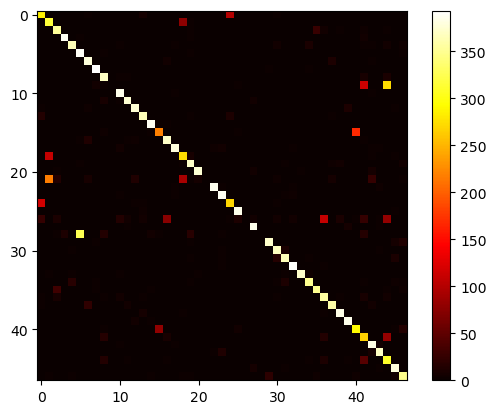

0.813784

In [38]:
model2 = OCRCNN()
model2.load_state_dict(torch.load(r'C:\Jupyters\OCR Neural Network\OCRModel_GELU Small 20Epoch\OCRModel_3.015_3.0721_0.815.pth'))
model2.eval()
model2 = model2.to(device)
model2.predict(frame_test, frame_test.shape[0])
get_accuracy()